### Imports et configuration

In [ ]:
import cv2
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
import math

# Configuration pour afficher les graphiques directement dans le notebook
%matplotlib inline

### Chargement des données

In [3]:
def load_metadata_and_counts(dataset_dir: str) -> pd.DataFrame:
    """Lit les fichiers labels YOLO pour compter les insectes par image."""
    base_path = Path(dataset_dir)
    images_dir = base_path / "images"
    labels_dir = base_path / "labels"
    
    data = []
    
    for img_path in images_dir.glob("*.*"):
        if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
            continue
            
        jour = img_path.name[:8]
        label_path = labels_dir / img_path.with_suffix(".txt").name
        
        insect_count = 0
        if label_path.exists():
            with open(label_path, 'r') as f:
                lines = [line.strip() for line in f.readlines() if line.strip()]
                insect_count = len(lines)
                
        data.append({
            "image_name": img_path.name,
            "image_path": str(img_path),
            "jour": jour,
            "insect_count": insect_count
        })
        
    return pd.DataFrame(data)

# Chargement depuis le sous-dossier de 'data' (ajuste le ../ si ton notebook est à la racine)
DATASET_DIR = "../data/merged_filtered_dataset" 

print("Analyse des fichiers et comptage des insectes en cours...")
df_stats = load_metadata_and_counts(DATASET_DIR)

# Afficher les 5 premières lignes pour vérifier interactivement
df_stats.head()

Analyse des fichiers et comptage des insectes en cours...


,image_name,image_path,jour,insect_count
0,20221006_09-03-49-024129_raw_jpg.rf.4df65bba71...,..\data\merged_filtered_dataset\images\2022100...,20221006,1
1,20221006_09-11-26-908410_raw_jpg.rf.d17c0ef063...,..\data\merged_filtered_dataset\images\2022100...,20221006,0
2,20221006_09-14-31-840309_raw_jpg.rf.28d2caeab7...,..\data\merged_filtered_dataset\images\2022100...,20221006,1
3,20221006_09-14-34-972005_raw_jpg.rf.5a5d09316b...,..\data\merged_filtered_dataset\images\2022100...,20221006,1
4,20221006_09-14-44-434197_raw_jpg.rf.b0129cf391...,..\data\merged_filtered_dataset\images\2022100...,20221006,1


### Distribution du nombre d'insectes par jour / par heures

=== Statistiques descriptives par jour ===


,Nb_images,Min_insectes,Max_insectes,Moyenne_insectes,Ecart_type
jour,,,,,
20221006,386,0,5,1.62,0.86
20221007,114,0,4,2.44,0.99
20221012,95,0,2,1.00,0.33
20221017,107,0,4,1.68,0.68
20221018,148,1,4,1.97,0.58
20221019,185,0,6,2.07,1.18
20221020,66,0,3,1.20,0.61


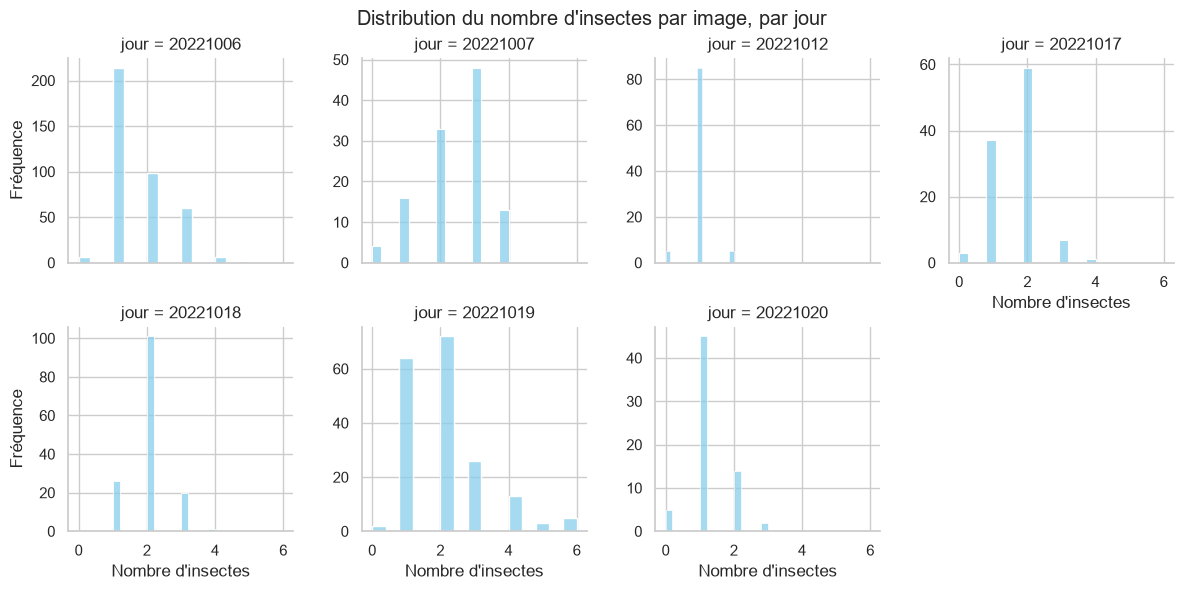

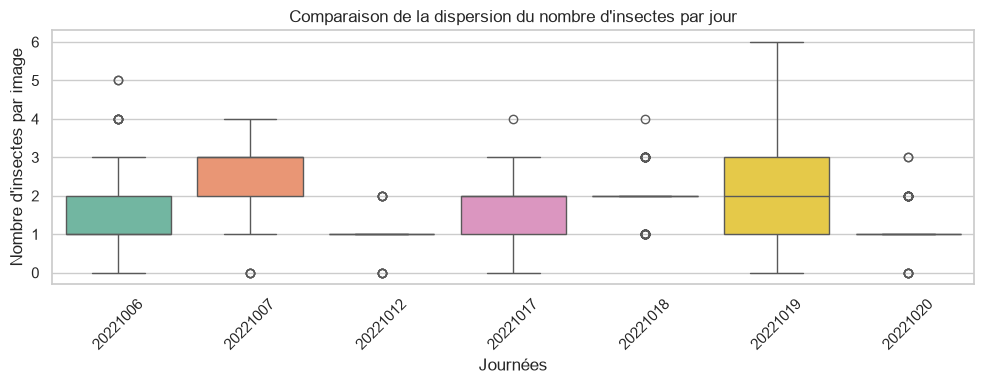

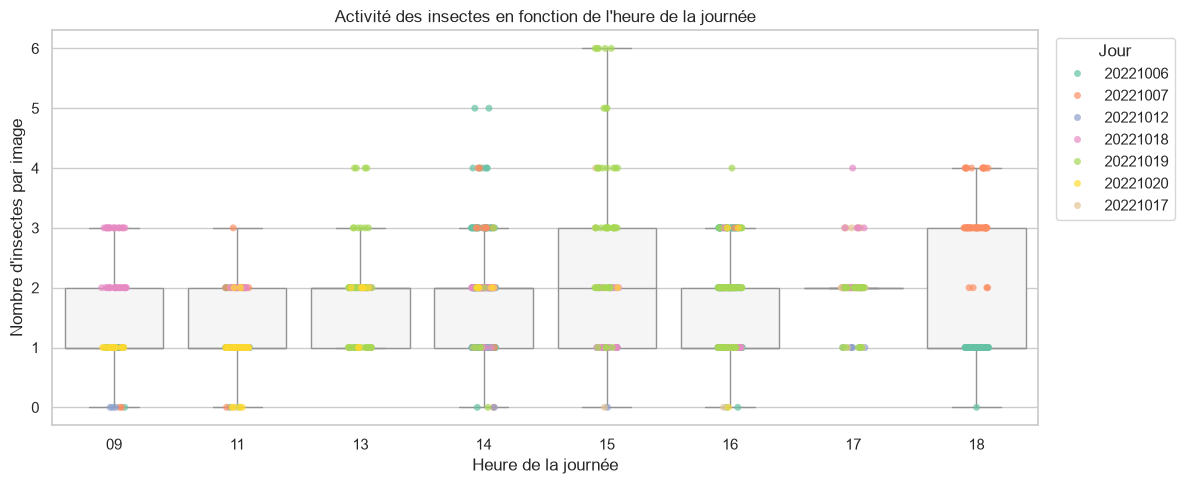

In [10]:
def display_summary_and_plots(df: pd.DataFrame):
    sns.set_theme(style="whitegrid")
    
    # --- 1. Création du tableau récapitulatif ---
    print("=== Statistiques descriptives par jour ===")
    summary = df.groupby("jour")["insect_count"].agg(
        Nb_images='count',
        Min_insectes='min',
        Max_insectes='max',
        Moyenne_insectes='mean',
        Ecart_type='std'
    ).round(2)
    display(summary)
    
    # --- 2. Graphiques de distribution par Jour ---
    g = sns.FacetGrid(df, col="jour", col_wrap=4, height=3, sharey=False)
    g.map(sns.histplot, "insect_count", bins=15, color="skyblue")
    g.set_axis_labels("Nombre d'insectes", "Fréquence")
    g.fig.subplots_adjust(top=0.9)
    g.fig.suptitle("Distribution du nombre d'insectes par image, par jour")
    plt.show()
    
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=df, x="jour", y="insect_count", hue="jour", palette="Set2", legend=False)
    plt.title("Comparaison de la dispersion du nombre d'insectes par jour")
    plt.xlabel("Journées")
    plt.ylabel("Nombre d'insectes par image")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # --- 3. Graphiques de distribution par Heure ---
    plt.figure(figsize=(12, 5))
    
    # Tri par heure pour avoir un axe X chronologique propre
    df_sorted = df.sort_values("heure")
    
    # Un boxplot gris pour la tendance générale de l'heure
    sns.boxplot(data=df_sorted, x="heure", y="insect_count", color="whitesmoke", showfliers=False)
    
    # Superposition d'un nuage de points coloré par jour
    sns.stripplot(data=df_sorted, x="heure", y="insect_count", hue="jour", palette="Set2", alpha=0.7, jitter=True)
    
    plt.title("Activité des insectes en fonction de l'heure de la journée")
    plt.xlabel("Heure de la journée")
    plt.ylabel("Nombre d'insectes par image")
    plt.legend(title="Jour", bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Extraction de l'heure (caractères 9 et 10 du nom de fichier)
df_stats["heure"] = df_stats["image_name"].str[9:11]

# Lancement de la visualisation mise à jour
display_summary_and_plots(df_stats)

### Aperçu visuel des conditions environnementales (luminosité, cadrage)

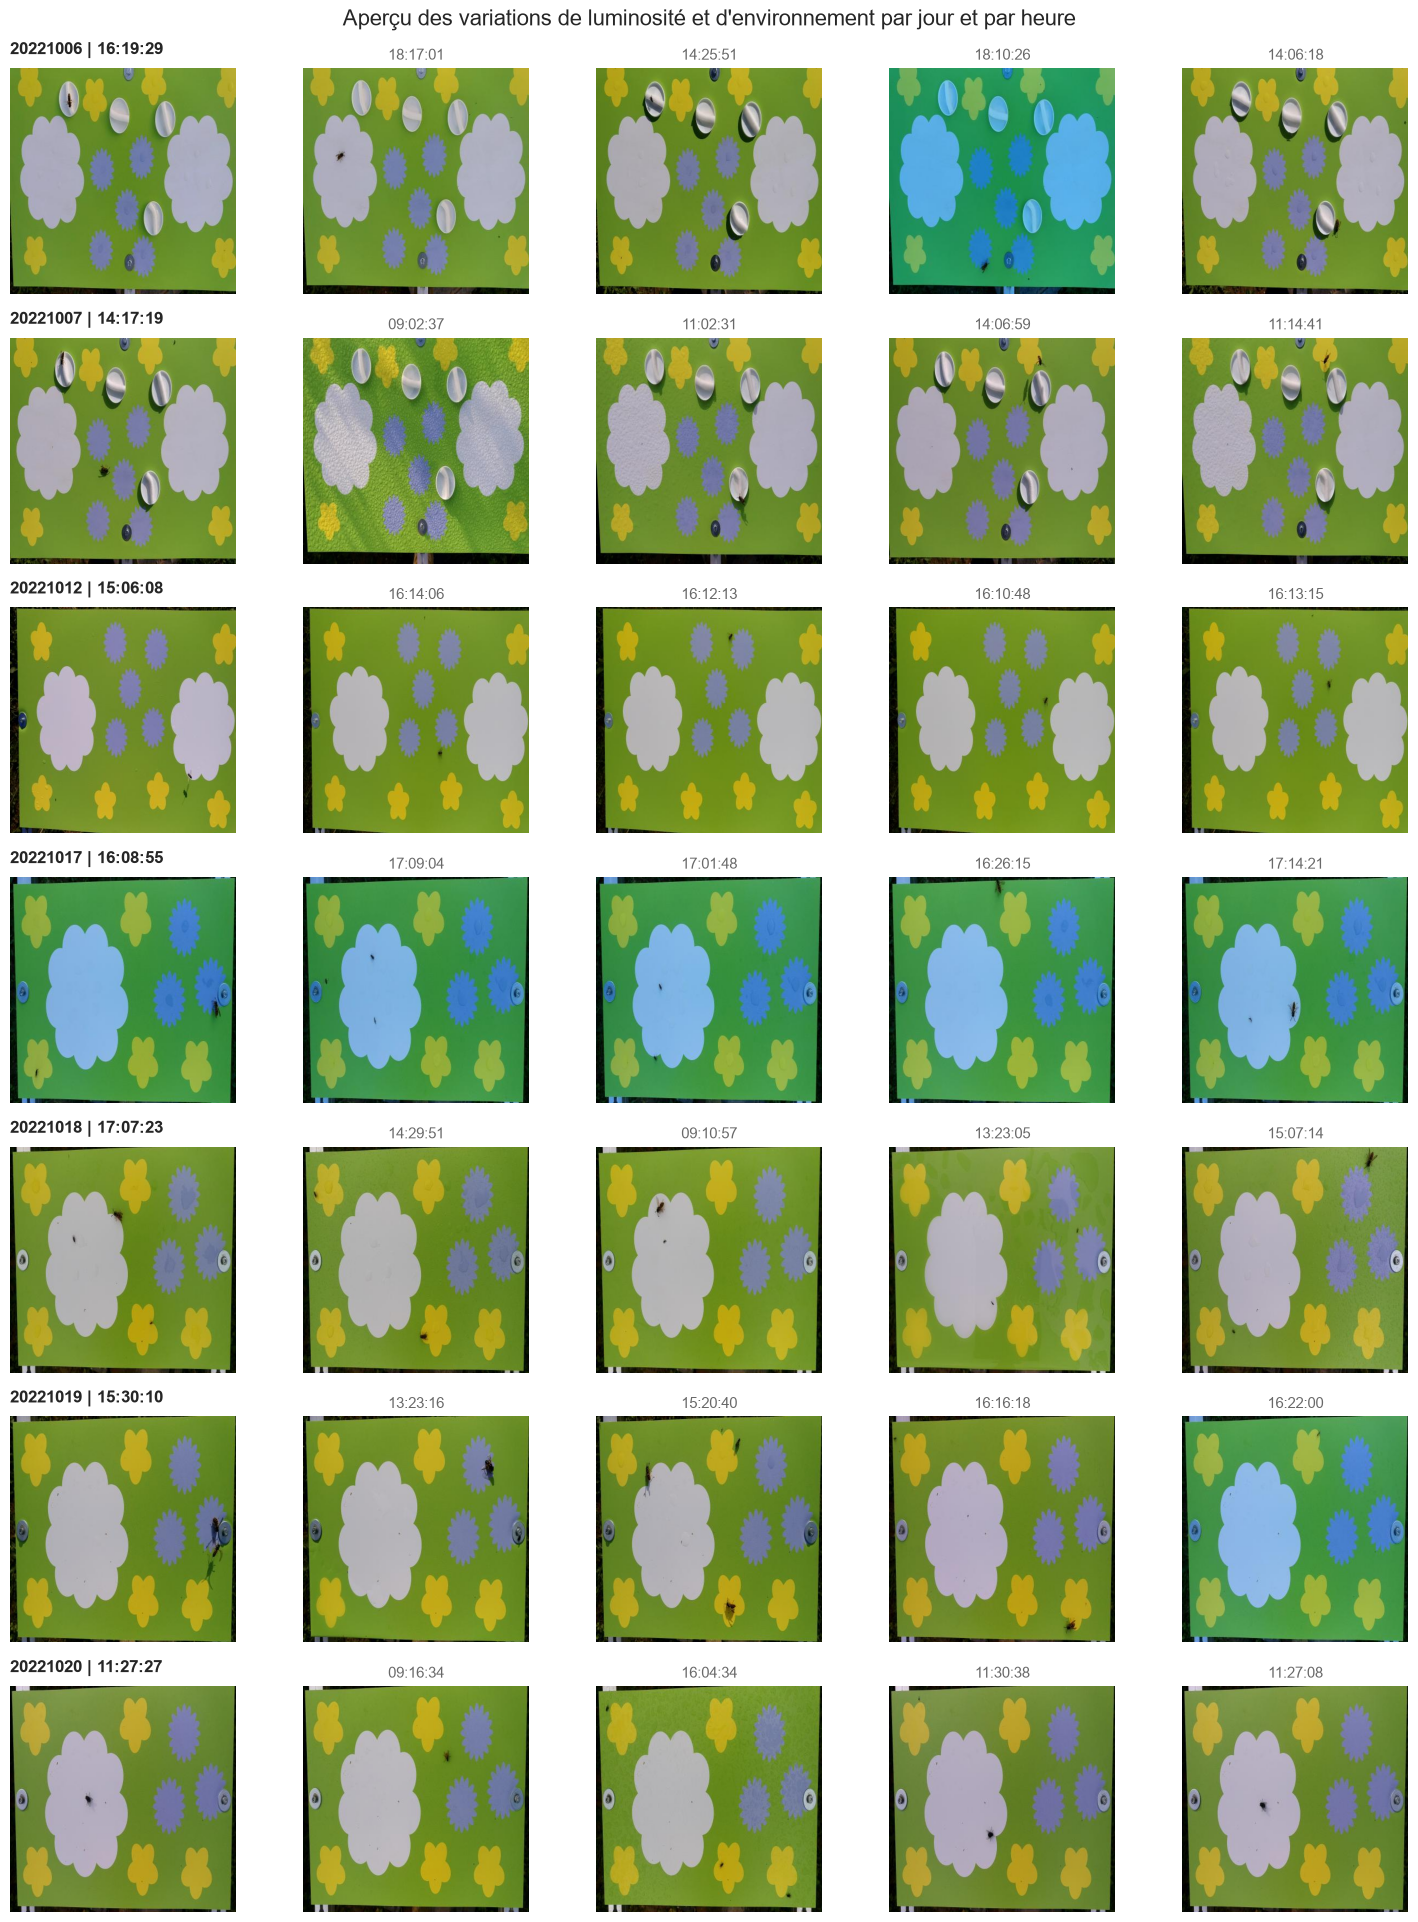

In [19]:
def plot_daily_thumbnails(df: pd.DataFrame, n_samples: int = 5):
    """Affiche une grille d'images avec la date et l'heure exacte de la prise de vue."""
    jours = sorted(df["jour"].unique())
    n_jours = len(jours)
    
    fig, axes = plt.subplots(n_jours, n_samples, figsize=(15, 2.8 * n_jours))
    fig.suptitle("Aperçu des variations de luminosité et d'environnement par jour et par heure", fontsize=16)
    
    for i, jour in enumerate(jours):
        df_jour = df[df["jour"] == jour]
        # On garde les lignes entières pour avoir accès aux noms de fichiers
        samples = df_jour.sample(min(n_samples, len(df_jour)))
        
        for j, (_, row) in enumerate(samples.iterrows()):
            img_path = row["image_path"]
            img = cv2.imread(img_path)
            if img is not None:
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                axes[i, j].imshow(img_rgb)
            
            axes[i, j].axis('off')
            
            # Extraction de l'heure exacte depuis 'YYYYMMDD_HH-MM-SS...'
            # Les caractères de l'indice 9 à 17 correspondent à 'HH-MM-SS'
            heure_exacte = row["image_name"][9:17].replace("-", ":")
            
            # Affichage de la date + heure sur la première colonne, juste l'heure sur les autres
            if j == 0:
                axes[i, j].set_title(f"{jour} | {heure_exacte}", fontsize=12, loc='left', pad=10, fontweight='bold')
            else:
                axes[i, j].set_title(heure_exacte, fontsize=11, color="dimgray")
                
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.show()

plot_daily_thumbnails(df_stats)

### Etude de la teinte particulière de certaines images

Génération de la chronologie complète par jour...


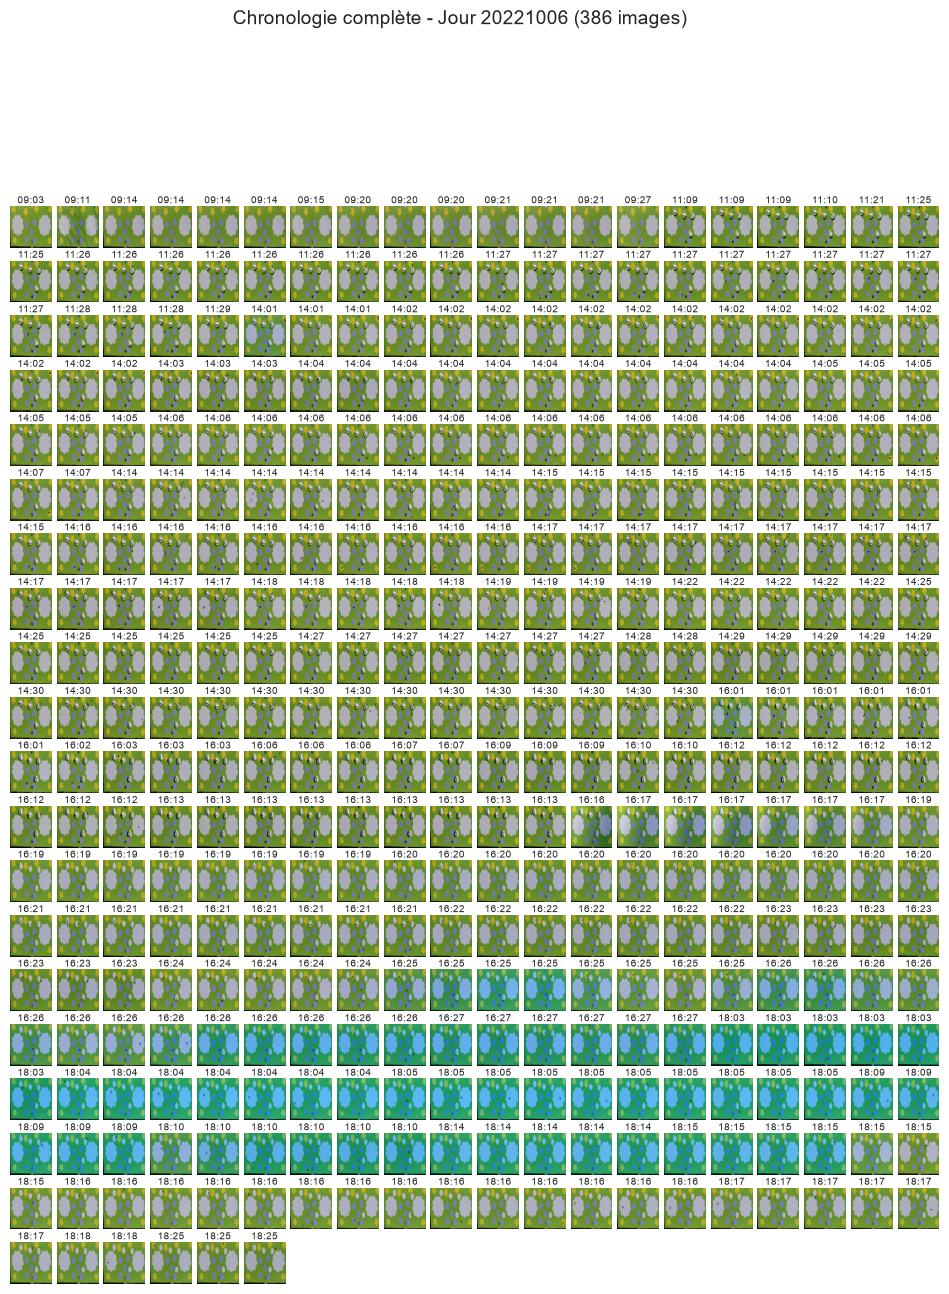

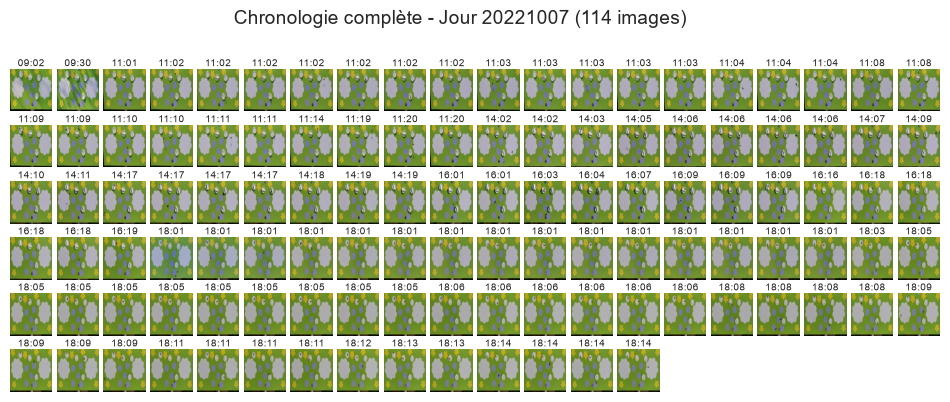

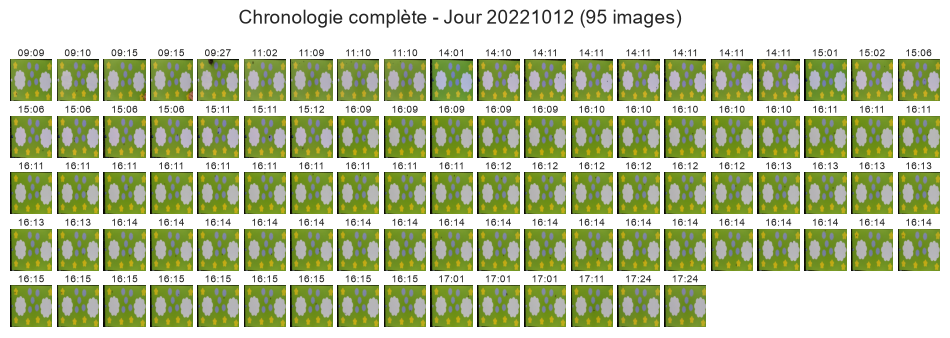

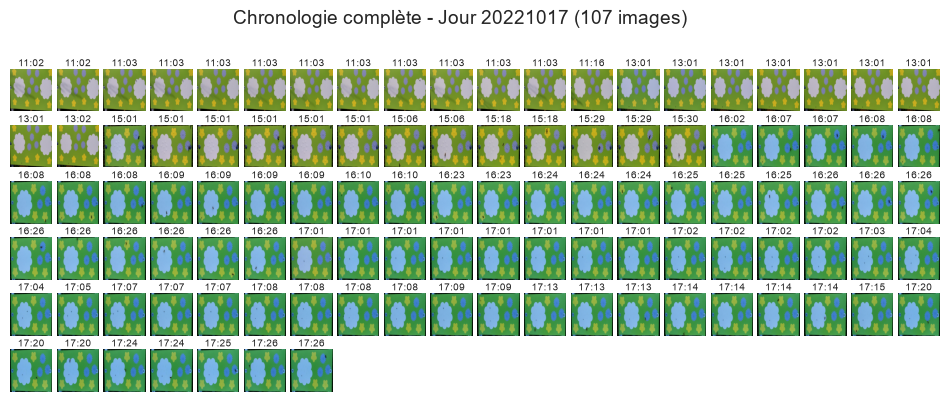

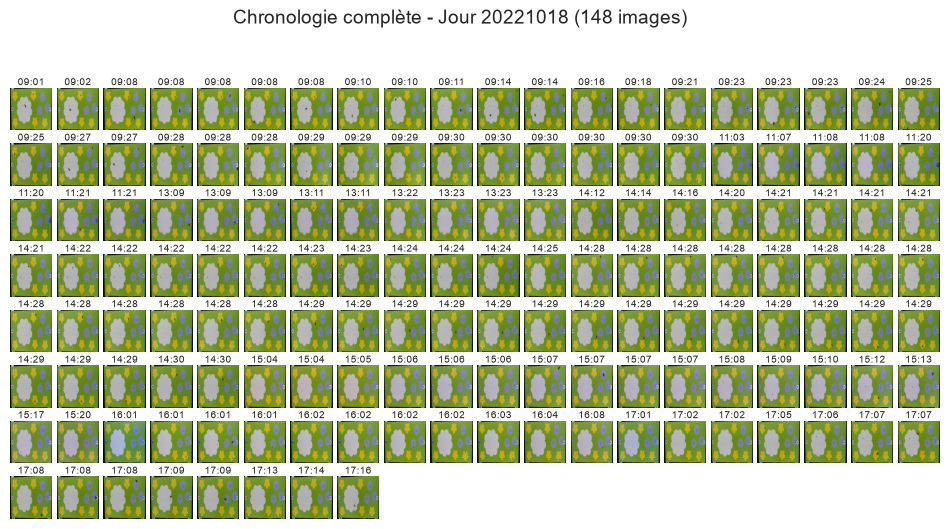

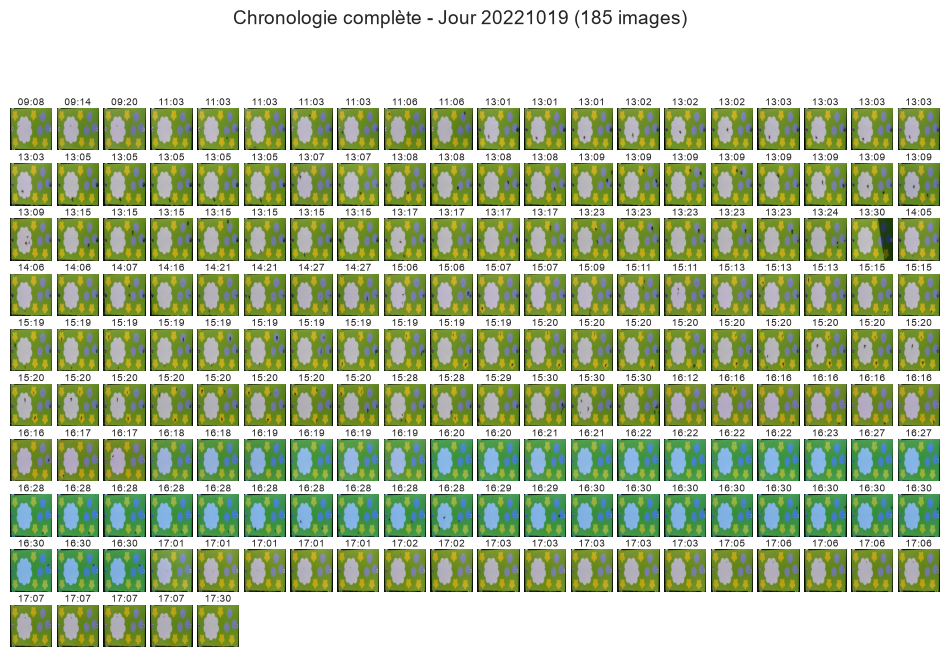

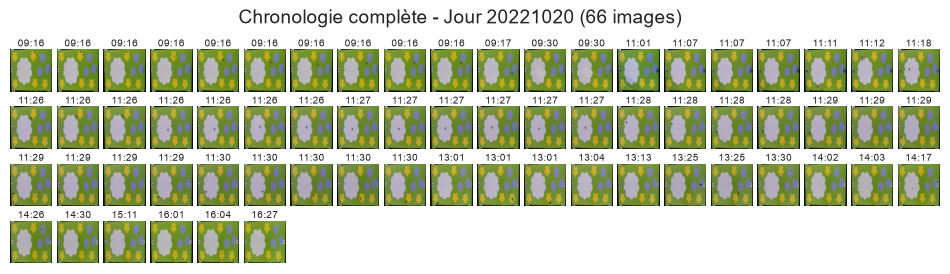

In [22]:
def plot_all_thumbnails_chronological(df: pd.DataFrame, cols: int = 20):
    """
    Affiche toutes les images d'un jour, triées chronologiquement, 
    sous forme de grille de miniatures très compactes.
    """
    jours = sorted(df["jour"].unique())
    
    for jour in jours:
        # Filtrer et trier par ordre chronologique (via le nom du fichier)
        df_jour = df[df["jour"] == jour].sort_values("image_name")
        n_images = len(df_jour)
        
        # Calculer le nombre de lignes nécessaires pour la grille
        rows = math.ceil(n_images / cols)
        
        # Taille riquiqui : 0.6 pouce par miniature
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 0.6, rows * 0.7))
        fig.suptitle(f"Chronologie complète - Jour {jour} ({n_images} images)", fontsize=14, y=1.02)
        
        # Aplatir le tableau d'axes pour l'itération
        axes = axes.flatten()
        
        for idx, (_, row) in enumerate(df_jour.iterrows()):
            img = cv2.imread(row["image_path"])
            if img is not None:
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                axes[idx].imshow(img_rgb)
            
            # Afficher juste Heure:Minute en tout petit pour ne pas surcharger
            heure_minute = row["image_name"][9:14].replace("-", ":")
            axes[idx].set_title(heure_minute, fontsize=7, pad=2)
            axes[idx].axis('off')
            
        # Désactiver les cadres vides restants à la fin de la grille
        for idx in range(n_images, len(axes)):
            axes[idx].axis('off')
            
        plt.subplots_adjust(wspace=0.1, hspace=0.3)
        plt.show()

# Lancement de l'affichage complet
print("Génération de la chronologie complète par jour...")
plot_all_thumbnails_chronological(df_stats, cols=20)